# Notebook 06A – Bavian data: Databehandling

Jeg arbejder med data fra bavianer (*P. Papio*) baseret på Sørensen et al. (2023). Datasættet indeholder VCF/VCZ-data for kromosom 20 med:

- 227 diploide individer (454 haploide genomer)
- Multiple bavian-arter og populationer

Bavian-arter i datasættet - 6 arter:

- *P. cynocephalus* (Yellow bavian) 
- *P. kindae* (Kinda bavian)   
- *P. anubis* (Olive bavian) 
- *P. papio* (Guinea bavian) 
- *P. ursinus* (Chacma bavian) 
- *P. hamadryas* (Hamadryas bavian)

I denne notebook estimerer jeg den effektive populationsstørrelse ($N_e$)for seks bavianpopulationer (*Papio*) ud fra hele-genome sekvensdata fra kromosom 20. Jeg bruger Kingmans coalescent implementeret som fase-type fordeling i phasic og infererer posterior-fordelingen for coalescentraten $\theta$ via SVGD.

Analysepipelinen følger den konfiguration, der blev fastlagt i NB02 (standard SVGD-konfiguration). Resultaterne bruges som udgangspunkt for de mere komplekse to-populations modeller i NB07B.

Sande konstanter (Sørensen et al. 2023):

- Mutationsrate: $\mu = 0{,}9 \times 10^{-8}$ per site per generation  

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"


# Importer nødvendige pakker
from phasic import (
    Graph, with_ipv, GaussPrior, DataPrior, HalfCauchyPrior, LogGaussPrior,
    Adam, Adamelia, ExpStepSize, ExpRegularization, clear_caches,
    StateIndexer, Property, PropertySet, set_log_level
)
import json, time
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme
import msprime

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")
plt.rcParams['figure.figsize'] = (8, 4)
import vscodenb
vscodenb.is_vscode_dark_theme = lambda: (False, 'white')
set_log_level("WARNING")


# Biologiske konstanter
MU = 0.9e-8   # mutationsrate per site per generation (Sørensen et al. 2023)
G  = 11       # generationstid i år (Sørensen et al. 2023) 

DATA_DIR = Path('/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR')
OUT_DIR  = Path('output')
OUT_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)


## Hjælpefunktioner

### Wattersons estimator

Wattersons $\hat{\theta}_W$ estimerer coalescentraten direkte fra allele counts:

$$\hat{\theta}_W = \frac{S}{a_n}$$

hvor $S = \sum_{i=1}^{n-1} \xi_i$ er antallet af segregerende sites og $a_n = \sum_{i=1}^{n-1} 1/i$ er den harmoniske normering.

Den bruges både som startpunkt for prioren og som sammenligning med SVGD-estimaterne.

In [2]:
def watterson_theta(df):
    n = int(df['nr_samples'].max())
    a_n = sum(1/i for i in range(1, n))
    seg = ((df['derived_count'] > 0) & (df['derived_count'] < df['nr_samples'])).sum()
    total_sites = len(df)
    return (seg / total_sites) / a_n


def build_coal_graph(n):
    @with_ipv([n] + [0]*(n-1))
    def coalescent_1param(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
                transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
        return transitions
    return Graph(coalescent_1param)

## Indlæs data

Jeg indlæser genomdata for kromosom 20 fra det fasede VCZ-datasæt. Data er gemt i Zarr-format og håndteres via *sgkit*.

- *sg.load_dataset()* åbner datasættet.
- *sg.count_variant_alleles()* tæller antal forekomster af hvert allel per variant (reference- og derived-allel)
- *ac[:, 1]* er derived allele count antal haploide genomer der bærer det alternativt allel. Dette antages at være det derived allel (dvs. ikke-ancestral)
- *nr_samples* er det totale antal haploide genomer per variant (= 2 × antal diploide individer, da data er fasede)

Det derived allele count for et SNP fortæller, hvor mange af de 454 haploide genomer der bærer den nyere variant. Dette er grundlaget for SFS-beregningen.

In [3]:
# Henter data for kromosom 20 
ds = sg.load_dataset(DATA_DIR / "chr20.phased.rehead.vcz")

variant_allele_counts = sg.count_variant_alleles(ds) # variant_allele_count har shape (variants, alleles), dtype uint64
ac = variant_allele_counts["variant_allele_count"].values   
nr_samples = ac.sum(axis=1)  

derived_variant_count_df = pd.DataFrame({
    "position": ds["variant_position"].values,
    "derived_count": ac[:, 1],
    "nr_samples": nr_samples,
})
derived_variant_count_df.head()

,position,derived_count,nr_samples
0,19,13,454
1,73,23,454
2,126,1,454
3,148,1,454
4,149,23,454


In [4]:
# Antal varianter og prøver
print(f"Antal varianter (chr20): {len(derived_variant_count_df):,}")
print(f"Totale haploid prøvestørrelse: {int(nr_samples.max())} ({int(nr_samples.max())//2} diploide individer)")

Antal varianter (chr20): 2,665,269
Totale haploid prøvestørrelse: 454 (227 diploide individer)


## Udvælg populationer

Sample-ID'erne følger mønsteret *PD_XXXX* (og *Sci_XXXXX* for nogle samples). Jeg tildeler hvert sample til en bavian-art baseret på tabellen (Tabel S2) fra Sørensen et al. (2023).

In [5]:
# Hent alle sample-ID'er 
sample_ids = ds['sample_id'].values
print(f"Antal prøver: {len(sample_ids)}")
print(f"Første 10 sample-ID'er: {sample_ids[:10]}")

Antal prøver: 227
Første 10 sample-ID'er: ['Sci_16066' 'Sci_16098' 'Sci_30877' 'Sci_30977' 'Sci_34449' 'Sci_34474'
 'Sci_38168' 'Sci_97074' 'Sci_97124' 'PD_0067']


In [6]:
# Udfylder med de korrekte sample-ID'er fra Tabel S2 i artiklen eller fra ds['sample_id'].values ovenfor.

population_map = {
    # P. cynocephalus - Tanzania (Ruaha + Udzungwa + Mahale + Katavi + Selous + Mikumi + Issa Valley)                                                         
    "P_cynocephalus":  ['PD_0213', 'PD_0214', 'PD_0215', 'PD_0216','PD_0217', 'PD_0223',
                         'PD_0224', 'PD_0225', 'PD_0226', 'PD_0227', 'PD_0228', 'PD_0229',
                         'PD_0230', 'PD_0231', 'PD_0232', 'PD_0233', 'PD_0234', 'PD_0235',
                         'PD_0236', 'PD_0237', 'PD_0229', 'PD_0230', 'PD_0231', 'PD_0232',
                         'PD_0233', 'PD_0234', 'PD_0235', 'PD_0236', 'PD_0237', 'PD_0268',
                         'PD_0269', 'PD_0270', 'PD_0271', 'PD_0272', 'PD_0503', 'PD_0637',
                         'PD_0658', 'PD_0659','PD_0662', 'PD_0687', 'PD_0688', 'PD_0689',
                         'PD_0690', 'PD_0691', 'PD_0745', 'PD_0746', 'PD_0747', 'PD_0748',
                         'PD_0752', 'PD_0753', 'PD_0754', 'PD_0755', 'PD_0756', 'PD_0757',
                         'PD_0761', 'PD_0762', 'PD_0763', 'PD_0764', 'PD_0765', 'PD_0766',
                         'PD_0767', 'PD_0768', 'PD_0769', 'PD_0770', 'PD_0771', 'PD_0772',
                         'PD_0773', 'PD_0774', 'PD_0775'],
    # P. Kindae - Chunga, Zambia      
    "P_kindae":               ['PD_0749','PD_0750','PD_0751', 'PD_0758', 'PD_0759', 'PD_0760',
                            'PD_0776', 'PD_0777', 'PD_0778', 'PD_0779', 'PD_0780', 'PD_0781',
                            'PD_0782', 'PD_0783', 'PD_0784', 'PD_0785', 'PD_0786', 'PD_0787',
                            'PD_0788', 'PD_0789', 'PD_0790', 'PD_0791', 'PD_0792', 'PD_0793',
                            'PD_0794_BAB'],
    # P. Anubis - Tanzania (Lake Manyara, Ngorongoro, Serengeti, Tarangire, Gombe, Arusha), Ethiopia (Gog)
    "P_anubis":         ['PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203', 'PD_0208',
                            'PD_0209', 'PD_0210', 'PD_0211', 'PD_0212', 'PD_0218', 'PD_0219', 
                            'PD_0220', 'PD_0221', 'PD_0222', 'PD_0238', 'PD_0239', 'PD_0240', 
                            'PD_0241', 'PD_0242', 'PD_0243', 'PD_0244', 'PD_0265', 'PD_0266',
                            'PD_0267', 'PD_0492', 'PD_0493', 'PD_0494', 'PD_0495', 'PD_0496', 
                            'PD_0497', 'PD_0498', 'PD_0499', 'PD_0500', 'PD_0501', 'PD_0502', 
                            'PD_0504', 'PD_0505', 'PD_0506', 'PD_0507', 'PD_0508', 'PD_0509', 
                            'PD_0641', 'PD_0642', 'PD_0649', 'PD_0650', 'PD_0651', 'PD_0652',
                            'PD_0653', 'PD_0654', 'PD_0674', 'PD_0675', 'PD_0676', 'PD_0677', 
                            'PD_0678', 'PD_0679', 'PD_0680', 'PD_0681', 'PD_0682', 'PD_0683', 
                            'PD_0684', 'PD_0685', 'PD_0686', 'PD_0720', 'PD_0721', 
                            'PD_0722', 'PD_0723', 'PD_0724', 'PD_0725', 'PD_0726', 'PD_0727', 
                            'PD_0728', 'PD_0729', 'PD_0730', 'PD_0731', 'PD_0732', 'PD_0733', 
                            'PD_0734', 'PD_0735', 'PD_0736', 'PD_0737', 'PD_0738' 'PD_0739', 
                            'PD_0740', 'PD_0741', 'PD_0742', 'PD_0743', 'PD_0744', 'PD_0204', 
                            'PD_0205', 'PD_0206', 'PD_0207',],
    # P. Papio - Niokolo Koba, Senegal
    "P_papio":          ['PD_0390', 'PD_0391',
                         'PD_0392', 'PD_0393', 'PD_0394', 'PD_0395', 'PD_0396', 'PD_0397', 
                         'PD_0398', 'PD_0399', 'PD_0400', 'PD_0401', 'PD_0397', 'PD_0398', 
                         'PD_0399', 'PD_0400', 'PD_0401'],
    # P. Ursinus (Grayfoot) - Dendro Park, Zambia
    "P_ursinus":        ['PD_0692', 'PD_0693', 'PD_0694', 'PD_0695', 'PD_0695'],
    # P. Hamadryas - Filoha, Ethiopia
    "P_hamadryas":     ['PD_0696', 'PD_0697', 'PD_0698', 'PD_0699', 'PD_0700', 'PD_0701',
                        'PD_0702', 'PD_0703', 'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707',
                        'PD_0708', 'PD_0709', 'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713',
                        'PD_0714', 'PD_0715', 'PD_0716', 'PD_0717', 'PD_0718', 'PD_0719', 
                        'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707', 'PD_0708', 'PD_0709',
                        'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713', 'PD_0714', 'PD_0715', 
                        'PD_0716', 'PD_0717', 'PD_0718', 'PD_0719'],                                                           
}

In [7]:
# Udtrækker subsets 
keep = population_map["P_cynocephalus"]
mask = ds["sample_id"].isin(keep).values
ds_P_cynocephalus = ds.isel(samples=mask)

keep = population_map["P_kindae"]
mask = ds["sample_id"].isin(keep).values
ds_P_kindae = ds.isel(samples=mask)

keep = population_map["P_anubis"]
mask = ds["sample_id"].isin(keep).values
ds_P_anubis = ds.isel(samples=mask)

keep = population_map["P_papio"]
mask = ds["sample_id"].isin(keep).values
ds_P_papio = ds.isel(samples=mask)

keep = population_map["P_ursinus"]
mask = ds["sample_id"].isin(keep).values
ds_P_ursinus = ds.isel(samples=mask)

keep = population_map["P_hamadryas"]
mask = ds["sample_id"].isin(keep).values
ds_P_hamadryas = ds.isel(samples=mask)


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Yellow baboon: {ds_P_cynocephalus.dims['samples']} prøver")
print(f"Kinda baboon:  {ds_P_kindae.dims['samples']} prøver")
print(f"Olive baboon: {ds_P_anubis.dims['samples']} prøver")
print(f"Guinea baboon: {ds_P_papio.dims['samples']} prøver")
print(f"Chacma baboon: {ds_P_ursinus.dims['samples']} prøver")
print(f"Hamadryas baboon: {ds_P_hamadryas.dims['samples']} prøver")

Yellow baboon: 60 prøver
Kinda baboon:  25 prøver
Olive baboon: 90 prøver
Guinea baboon: 12 prøver
Chacma baboon: 4 prøver
Hamadryas baboon: 24 prøver


In [8]:
def extract_pop(ds, ids):
    mask = np.isin(ds['sample_id'].values, ids)
    return ds.isel(samples=mask)

ds_pops = {name: extract_pop(ds, ids) for name, ids in population_map.items()}

pop_n = {name: ds_pops[name].sizes['samples'] * 2 for name in ds_pops}
for name, n in pop_n.items(): 
    print(f"{name:<22}: n={n} haplotyper ({n//2} individer)")
n_min = min(pop_n.values())
print(f"\nMindste population: n={n_min} (bruges til sammenligning)")

P_cynocephalus        : n=120 haplotyper (60 individer)
P_kindae              : n=50 haplotyper (25 individer)
P_anubis              : n=180 haplotyper (90 individer)
P_papio               : n=24 haplotyper (12 individer)
P_ursinus             : n=8 haplotyper (4 individer)
P_hamadryas           : n=48 haplotyper (24 individer)

Mindste population: n=8 (bruges til sammenligning)


## Beregn alleltal pr. population

Jeg beregner afledte variantantal (singletons, doubletons, osv.) for hver population. Disse tal danner grundlaget for SFS analysen og for at fitte koalescent modeller.

In [9]:
def compute_derived_counts(ds_pop, pop_name="population"):
    variant_allele_counts = sg.count_variant_alleles(ds_pop)
    ac = variant_allele_counts["variant_allele_count"].values
    nr_samples = ac.sum(axis=1)

    df = pd.DataFrame({
        "position":  ds_pop["variant_position"].values,
        "derived_count": ac[:, 1],
        "nr_samples": nr_samples,
    })

    # Behold kun segregerende SNPs
    df = df[(df["derived_count"] > 0) & (df["derived_count"] < df["nr_samples"])].copy()
    n  = int(df["nr_samples"].max())
    print(f"{pop_name}: {len(df):,} segregerende SNPs  (n={n} haplotyper = {n//2} individer)")
    return df

df_P_cynocephalus = compute_derived_counts(ds_P_cynocephalus, "Yellow Baboon")
df_P_kindae  = compute_derived_counts(ds_P_kindae,  "Kinda Baboon")
df_P_anubis = compute_derived_counts(ds_P_anubis, "Olive Baboon")
df_P_papio = compute_derived_counts(ds_P_papio, "Guinea Baboon")
df_P_ursinus = compute_derived_counts(ds_P_ursinus, "Chacma Baboon")
df_P_hamadryas = compute_derived_counts(ds_P_hamadryas, "Hamadryas Baboon")

Yellow Baboon: 1,379,280 segregerende SNPs  (n=120 haplotyper = 60 individer)
Kinda Baboon: 833,071 segregerende SNPs  (n=50 haplotyper = 25 individer)
Olive Baboon: 1,058,781 segregerende SNPs  (n=180 haplotyper = 90 individer)
Guinea Baboon: 110,086 segregerende SNPs  (n=24 haplotyper = 12 individer)
Chacma Baboon: 403,120 segregerende SNPs  (n=8 haplotyper = 4 individer)
Hamadryas Baboon: 460,025 segregerende SNPs  (n=48 haplotyper = 24 individer)


In [10]:
df_P_cynocephalus.head()

,position,derived_count,nr_samples
1,73,7,120
2,126,1,120
4,149,22,120
6,236,4,120
7,283,73,120


In [11]:
df_P_kindae.head()

,position,derived_count,nr_samples
1,73,16,50
5,162,4,50
7,283,8,50
19,732,11,50
22,858,8,50


In [12]:
df_P_anubis.head()

,position,derived_count,nr_samples
4,149,1,180
6,236,37,180
7,283,12,180
9,450,3,180
13,501,1,180


In [13]:
df_P_papio.head()

,position,derived_count,nr_samples
0,19,13,24
194,8377,21,24
195,8378,21,24
198,8391,20,24
199,8401,20,24


In [14]:
df_P_ursinus.head()

,position,derived_count,nr_samples
3,148,1,8
17,654,1,8
35,1814,2,8
44,2190,1,8
48,3214,3,8


In [15]:
df_P_hamadryas.head()

,position,derived_count,nr_samples
13,501,17,48
25,953,12,48
40,1971,4,48
42,2144,10,48
43,2189,3,48


In [16]:
def compute_derived_counts(ds_pop, pop_name=""):
    from sgkit import count_variant_alleles
    vac = count_variant_alleles(ds_pop)
    ac  = vac["variant_allele_count"].values
    nr  = ac.sum(axis=1)
    df  = pd.DataFrame({
        "position":      ds_pop["variant_position"].values,
        "derived_count": ac[:, 1],
        "nr_samples":    nr,
    })
    df = df[(df["derived_count"] > 0) & (df["derived_count"] < df["nr_samples"])].copy()
    if pop_name:
        print(f"{pop_name:<22}: {len(df):>8,} SNPs  n_hap={int(df['nr_samples'].max())}")
    return df

populations = {name: compute_derived_counts(ds_pops[name], name) for name in ds_pops}

P_cynocephalus        : 1,379,280 SNPs  n_hap=120
P_kindae              :  833,071 SNPs  n_hap=50
P_anubis              : 1,058,781 SNPs  n_hap=180
P_papio               :  110,086 SNPs  n_hap=24
P_ursinus             :  403,120 SNPs  n_hap=8
P_hamadryas           :  460,025 SNPs  n_hap=48


## Nukleotiddiversitet, $N_{ref}$ og Tajimas $D$

Alle beregninger bruger den fulde populationsstørrelse per art.
Fra NB01: $E[H] = 2*(1-1/n)$, Wattersons $a_n$ verificeret til $< 1e-6$ relativ afvigelse.

In [17]:
def nucleotide_diversity(df):
    n  = df['nr_samples'].values.astype(float)
    ac = df['derived_count'].values.astype(float)
    p  = ac / n
    L  = int(df['position'].max() - df['position'].min()) + 1
    return (2 * p * (1 - p) * n / (n - 1)).sum() / L

def watterson_theta(df):
    n   = int(df['nr_samples'].max())
    a_n = sum(1/k for k in range(1, n))
    S   = len(df)
    L   = int(df['position'].max() - df['position'].min()) + 1
    return (S / a_n) / L

def tajimas_d(df):
    n = int(df['nr_samples'].max())
    S = len(df)  # antal segregerende sites
    if S == 0 or n < 2: return np.nan
    a1 = sum(1/i for i in range(1, n))
    a2 = sum(1/i**2 for i in range(1, n))
    b1 = (n + 1) / (3 * (n - 1))
    b2 = 2 * (n**2 + n + 3) / (9 * n * (n - 1))
    c1 = b1 - 1/a1
    c2 = b2 - (n + 2)/(a1 * n) + a2/a1**2
    e1 = c1 / a1
    e2 = c2 / (a1**2 + a2)
    n_arr  = df['nr_samples'].values.astype(float)
    ac_arr = df['derived_count'].values.astype(float)
    p_arr  = ac_arr / n_arr
    pi_total = (2 * p_arr * (1 - p_arr) * n_arr / (n_arr - 1)).sum()
    theta_W = S / a1
    denom = np.sqrt(e1 * S + e2 * S * (S - 1))
    if denom == 0: return np.nan

    return (pi_total - theta_W) / denom

N_ref_dict = {}
rows_pop = []
for name, df in populations.items():
    pi  = nucleotide_diversity(df)
    tW  = watterson_theta(df)
    D   = tajimas_d(df)
    Nr  = pi / (4 * MU)
    N_ref_dict[name] = Nr
    rows_pop.append({
        'Population': name, 'n_hap': int(df['nr_samples'].max()),
        f'π': round(pi, 6), f'θ_W': round(tW, 6),
        'N_ref': round(Nr), 'Tajimas D': round(D, 3) if not np.isnan(D) else np.nan,
    })  
df_pop = pd.DataFrame(rows_pop)
df_pop

,Population,n_hap,π,θ_W,N_ref,Tajimas D
0,P_cynocephalus,120,0.002946,0.003571,81843,-0.589
1,P_kindae,50,0.002793,0.002581,77584,0.301
2,P_anubis,180,0.002050,0.002548,56948,-0.637
3,P_papio,24,0.000512,0.000409,14217,1.019
4,P_ursinus,8,0.002233,0.002158,62034,0.192
5,P_hamadryas,48,0.001692,0.001439,46999,0.649


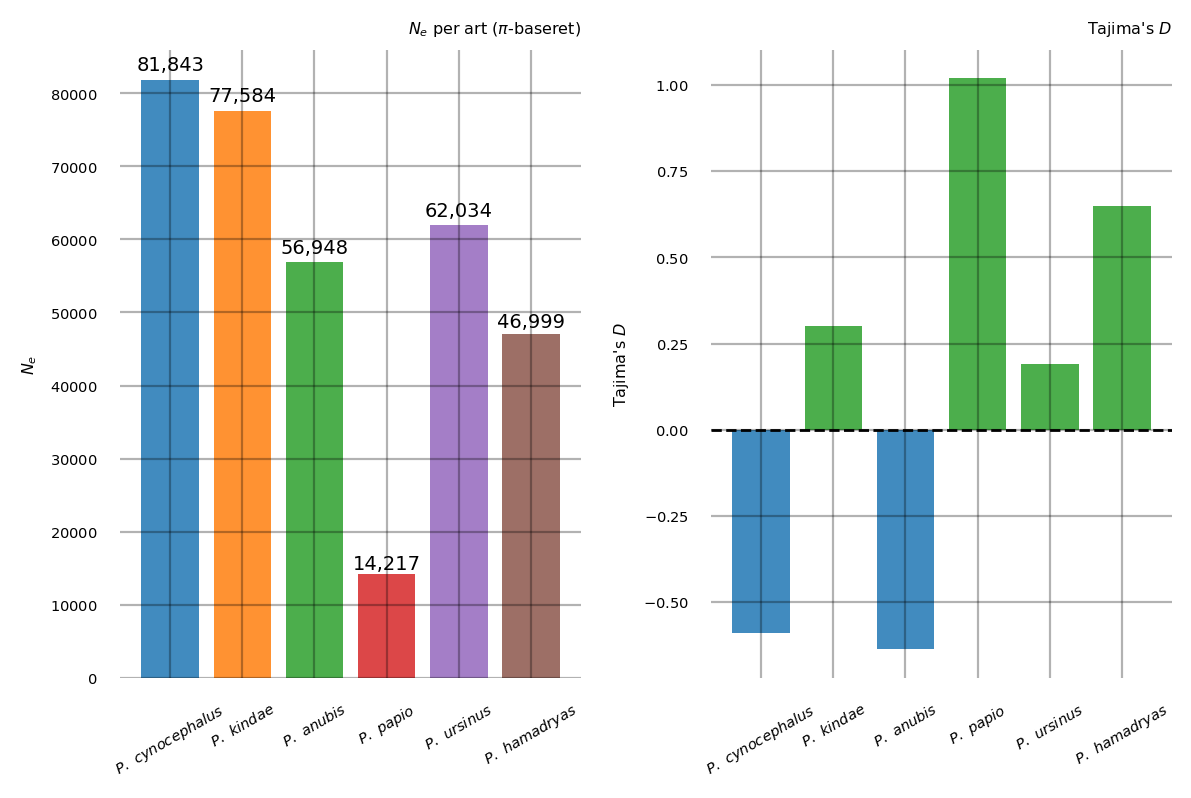

In [18]:
#| label: fig-ne-tajima
#| fig-cap: 'Reference-$N_e$ beregnet fra nukleotiddiversitet $\pi$ (venstre) og Tajimas $D$ (højre) for alle seks *Papio*-populationer. Hver søjle svarer til en art: orange (*P. cynocephalus*), blå (*P. kindae*), grøn (*P. anubis*), rød (*P. papio*), lilla (*P. ursinus*) og brun (*P. hamadryas*). Grøn farve i Tajimas $D$-panelet angiver positiv $D$ (flaskehals), blå angiver negativ $D$ (vækst/selektion). Den stiplede linje markerer $D=0$ (neutral forventning). *P. cynocephalus* og *P. anubis* har negativ $D$, konsistent med populationsvækst, mens *P. papio* har det højeste positive $D$, konsistent med en flaskehals.'
#| fig-width: 8
#| fig-height: 4
with sns.plotting_context("paper", font_scale=0.6):
    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    short_names = [r'$\it{P.\ cynocephalus}$', r'$\it{P.\ kindae}$', r'$\it{P.\ anubis}$',
               r'$\it{P.\ papio}$', r'$\it{P.\ ursinus}$', r'$\it{P.\ hamadryas}$']
    Ne_v = [r['N_ref'] for r in rows_pop]
    D_v  = [r['Tajimas D'] if not pd.isna(r['Tajimas D']) else 0 
            for r in rows_pop]

    axes[0].bar(short_names, Ne_v, 
                color=[f'C{i}' for i in range(len(short_names))], alpha=0.85)
    for bar, val in zip(axes[0].patches, Ne_v):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                    f'{val:,.0f}', ha='center', va='bottom', fontsize=7)
    axes[0].set_ylabel('$N_e$')
    axes[0].set_title(r'$N_e$ per art ($\pi$-baseret)')
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].bar(short_names, D_v, 
                color=['C2' if d > 0 else 'C0' for d in D_v], alpha=0.85)
    axes[1].axhline(0, color='k', linestyle='--', lw=1)
    axes[1].set_ylabel("Tajima's $D$")
    axes[1].set_title("Tajima's $D$")
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()


In [19]:
# Fortolkning
print("\nFortolkning af Tajima's D:")
for r in rows_pop:
    D = r['Tajimas D']
    if pd.isna(D): continue
    txt = "flaskehals/admixture" if D > 0.5 else "vækst/selektion" if D < -0.5 else "neutral"
    print(f"  {r['Population']:<22}: D={D:>6.3f}  => {txt}")


Fortolkning af Tajima's D:
  P_cynocephalus        : D=-0.589  => vækst/selektion
  P_kindae              : D= 0.301  => neutral
  P_anubis              : D=-0.637  => vækst/selektion
  P_papio               : D= 1.019  => flaskehals/admixture
  P_ursinus             : D= 0.192  => neutral
  P_hamadryas           : D= 0.649  => flaskehals/admixture


## SFS: Foldet og ufoldet med fuld n

Fra NB01: Singleton-andelen falder med $n$. Jeg bruger fuld $n$ per art til foldet SFS og subsampler til n_min for sammenligning på tværs af arter.

In [20]:
def folded_sfs(df, n_sub=None, n_obs=10_000, seed=42):
    if n_sub is None: n_sub = int(df['nr_samples'].max())
    rng = np.random.default_rng(seed)
    sfs = np.zeros(n_sub // 2)
    der = df['derived_count'].values.astype(int)
    tot = df['nr_samples'].values.astype(int)
    for idx in rng.integers(0, len(df), n_obs):
        n, ac = tot[idx], der[idx]
        if n < n_sub: continue
        k = min(rng.hypergeometric(ac, n-ac, n_sub), n_sub - rng.hypergeometric(ac, n-ac, n_sub))
        if 0 < k <= n_sub//2: sfs[k-1] += 1
    s = sfs.sum(); return sfs/s if s>0 else sfs

def unfolded_sfs(df, n_sub=None, n_obs=10_000, seed=42):
    if n_sub is None: n_sub = int(df['nr_samples'].max())
    rng = np.random.default_rng(seed)
    sfs = np.zeros(n_sub - 1)
    der = df['derived_count'].values.astype(int)
    tot = df['nr_samples'].values.astype(int)
    count = 0
    for idx in rng.integers(0, len(df), n_obs*10):
        if count >= n_obs: break
        n, ac = tot[idx], der[idx]
        if n < n_sub: continue
        k = rng.hypergeometric(ac, n-ac, n_sub)
        if 0 < k < n_sub: sfs[k-1] += 1; count += 1
    s = sfs.sum(); return sfs/s if s>0 else sfs

sfs_folded_full = {n: folded_sfs(df) for n, df in populations.items()}
sfs_unfolded_full = {n: unfolded_sfs(df) for n, df in populations.items()}
sfs_unfolded_min  = {n: unfolded_sfs(df, n_sub=n_min) for n, df in populations.items()}

for name in populations:
    n_full = int(populations[name]['nr_samples'].max())
    print(f"{name:<22}: {len(sfs_folded_full[name])} foldet bins (n_fuld={n_full}), "
          f"{len(sfs_unfolded_min[name])} ufoldet bins (n_min={n_min})")

P_cynocephalus        : 60 foldet bins (n_fuld=120), 7 ufoldet bins (n_min=8)
P_kindae              : 25 foldet bins (n_fuld=50), 7 ufoldet bins (n_min=8)
P_anubis              : 90 foldet bins (n_fuld=180), 7 ufoldet bins (n_min=8)
P_papio               : 12 foldet bins (n_fuld=24), 7 ufoldet bins (n_min=8)
P_ursinus             : 4 foldet bins (n_fuld=8), 7 ufoldet bins (n_min=8)
P_hamadryas           : 24 foldet bins (n_fuld=48), 7 ufoldet bins (n_min=8)


In [21]:
for name in populations:
    n_full = int(populations[name]['nr_samples'].max())
    print(f"{name:<22}: foldet={np.round(sfs_folded_full[name], 4)}")

P_cynocephalus        : foldet=[0.2095 0.1234 0.0844 0.0603 0.0446 0.0326 0.0321 0.0261 0.0233 0.0189
 0.0178 0.0165 0.0142 0.0134 0.0121 0.012  0.0119 0.0094 0.0094 0.0093
 0.0079 0.0082 0.0068 0.0087 0.0068 0.0073 0.0069 0.0076 0.0061 0.0059
 0.0053 0.0062 0.0061 0.0056 0.0059 0.0052 0.006  0.0056 0.0048 0.0053
 0.0033 0.0062 0.0051 0.0055 0.005  0.0045 0.0049 0.0043 0.0044 0.0044
 0.0046 0.0041 0.0048 0.005  0.0045 0.0053 0.0037 0.0037 0.0045 0.0028]
P_kindae              : foldet=[0.1668 0.0996 0.0822 0.071  0.0608 0.0462 0.0435 0.0416 0.0374 0.0305
 0.0295 0.0299 0.0249 0.0235 0.0222 0.0206 0.0228 0.0215 0.019  0.0202
 0.0176 0.0206 0.0186 0.0165 0.013 ]
P_anubis              : foldet=[0.1726 0.111  0.0744 0.0645 0.0437 0.0384 0.0334 0.0252 0.021  0.0178
 0.018  0.0177 0.0133 0.0147 0.0157 0.0108 0.0122 0.0116 0.0091 0.0092
 0.0075 0.0085 0.0072 0.0063 0.006  0.0073 0.0071 0.0076 0.0059 0.0054
 0.0072 0.0062 0.0041 0.005  0.005  0.0053 0.0038 0.0046 0.0052 0.0042
 0.0035 0.0047 0.

In [16]:
for name in populations:
    n_full = int(populations[name]['nr_samples'].max())
    print(f"{name:<22}: unfolded={np.round(sfs_unfolded_full[name], 4)}")

P_cynocephalus        : unfolded=[0.2022 0.1179 0.0795 0.0569 0.0421 0.0299 0.0288 0.0235 0.0209 0.016
 0.0156 0.0143 0.011  0.0112 0.0102 0.0104 0.0096 0.0078 0.0078 0.0075
 0.0061 0.0069 0.0051 0.0073 0.0055 0.0059 0.0058 0.0057 0.0047 0.005
 0.0038 0.0047 0.0044 0.0043 0.0039 0.0035 0.0039 0.0041 0.0032 0.0038
 0.0026 0.0045 0.0031 0.0037 0.0033 0.0024 0.0027 0.0025 0.0018 0.0022
 0.0032 0.002  0.0029 0.003  0.0022 0.0022 0.0023 0.0011 0.0021 0.0028
 0.0024 0.0026 0.0014 0.0031 0.0023 0.002  0.0019 0.0021 0.0014 0.0022
 0.0026 0.0018 0.0022 0.0021 0.0017 0.0018 0.002  0.0017 0.0007 0.0015
 0.0016 0.0015 0.0021 0.0017 0.002  0.0013 0.0017 0.0015 0.0015 0.0009
 0.0014 0.0019 0.0011 0.0014 0.0013 0.0014 0.0017 0.0013 0.0018 0.0018
 0.0016 0.0016 0.0023 0.0016 0.0019 0.0022 0.0032 0.0022 0.0022 0.0029
 0.0024 0.0026 0.0033 0.0027 0.0025 0.0034 0.0049 0.0055 0.0073]
P_kindae              : unfolded=[0.1576 0.0934 0.0771 0.067  0.055  0.0412 0.0386 0.036  0.0314 0.0248
 0.0235 0.0235 0.01

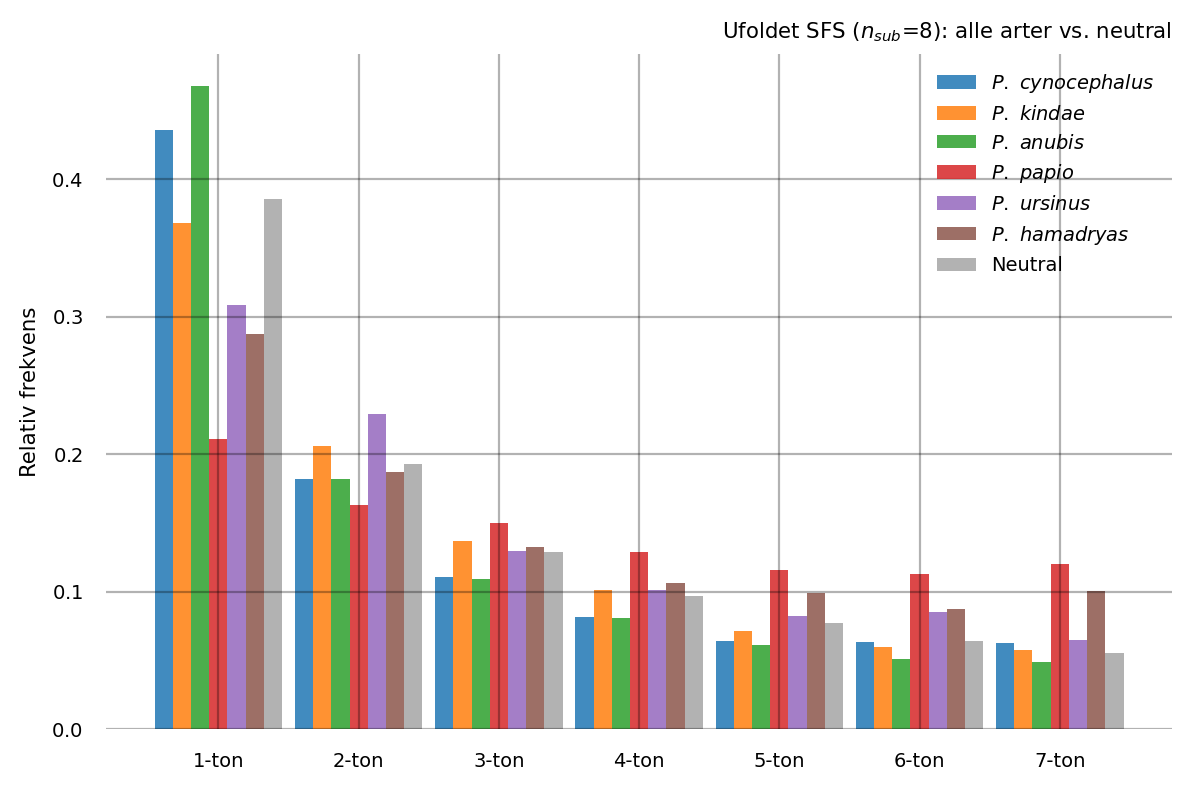

In [72]:
#| label: fig-sfs-bavian
#| fig-cap: 'Ufoldet site frekvens spektrum (SFS) for alle seks bavianarter subsampled til $n_{\text{min}} = 8$ haplotyper sammenlignet med det neutrale forventede SFS under konstant $N_e$ (grå søjle). X-aksen viser frekvensklassen (1-ton til 7-ton), og y-aksen viser relativ frekvens normaliseret til sum 1.'
#| fig-width: 8
#| fig-height: 4

# Ufoldet SFS
x = np.arange(n_min - 1); w = 0.13
short_names = [r'$\it{P.\ cynocephalus}$', r'$\it{P.\ kindae}$', r'$\it{P.\ anubis}$',
               r'$\it{P.\ papio}$', r'$\it{P.\ ursinus}$', r'$\it{P.\ hamadryas}$']

with sns.plotting_context("paper", font_scale=0.8):
    fig, ax = plt.subplots(figsize=(6, 4))
    for idx, (name, sfs) in enumerate(sfs_unfolded_min.items()):
        ax.bar(x + idx*w, sfs, w, label=short_names[idx], alpha=0.85)
    a_n = sum(1/k for k in range(1, n_min))
    neutral = [1/(k+1)/a_n for k in range(n_min-1)]
    ax.bar(x + len(sfs_unfolded_min)*w, neutral, w, label='Neutral', color='k', alpha=0.3)
    ax.set_xticks(x + w*3)
    ax.set_xticklabels([f"{i+1}-ton" for i in range(n_min-1)])
    ax.set_ylabel('Relativ frekvens')
    ax.set_title(fr'Ufoldet SFS ($n_{{sub}}$={n_min}): alle arter vs. neutral')
    ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()


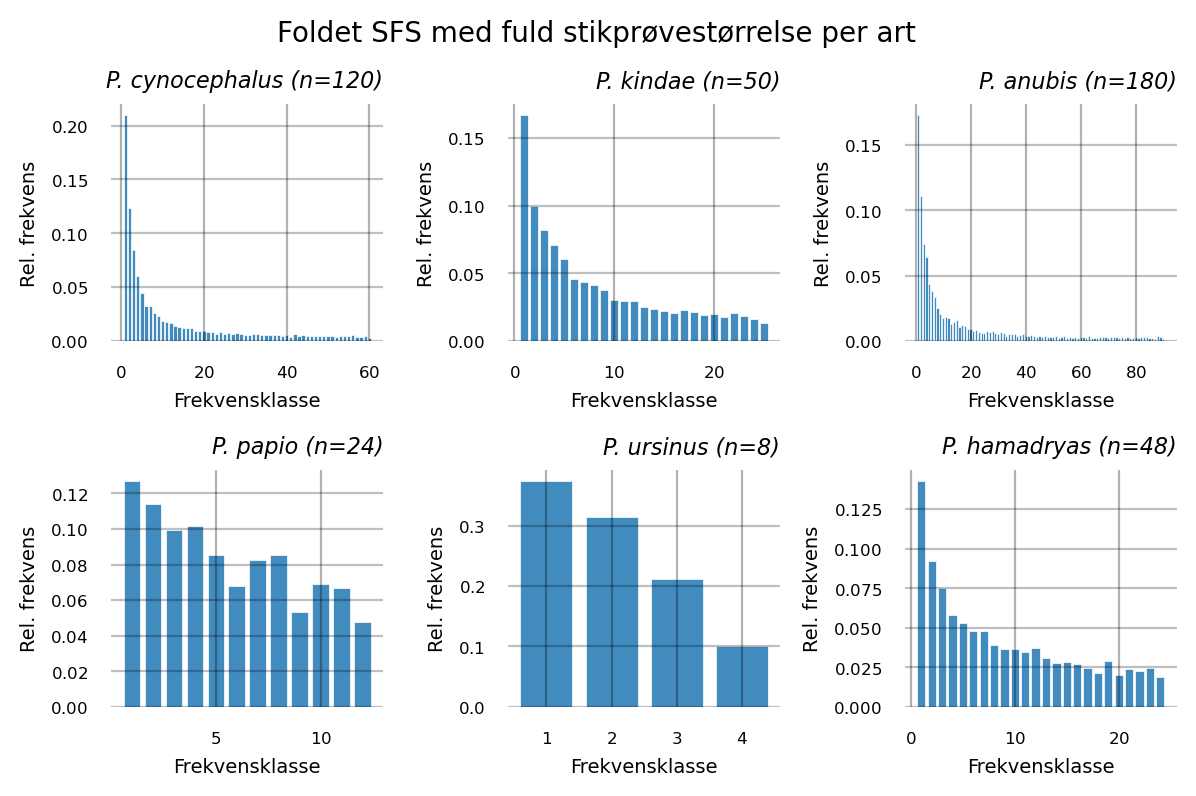

In [74]:
#| label: fig-sfs-foldet
#| fig-cap: 'Foldet site frekvens spektrum (SFS) for hver af de seks bavianarter med den fulde stikprøvestørrelse per art. X-aksen viser frekvensklassen op til $n/2$, og y-aksen viser relativ frekvens normaliseret til sum 1.'
#| fig-width: 9
#| fig-height: 5

with sns.plotting_context("paper", font_scale=0.7):
    fig, axes = plt.subplots(2, 3, figsize=(6, 4))
    for ax, (name, sfs) in zip(axes.flat, sfs_folded_full.items()):
        n_full = int(populations[name]['nr_samples'].max())
        ax.bar(np.arange(1, len(sfs)+1), sfs, alpha=0.85, width=0.8, edgecolor='white', linewidth=0.3)
        ax.set_title(f"{name.replace('P_', 'P. ')} (n={n_full})", style='italic', fontsize=8)
        ax.set_xlabel('Frekvensklasse', fontsize=7)
        ax.set_ylabel('Rel. frekvens', fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(alpha=0.25, axis='y')
        ax.spines[['top', 'right']].set_visible(False)
    fig.suptitle('Foldet SFS med fuld stikprøvestørrelse per art', fontsize=10)
    plt.tight_layout()
    plt.show()

## SVGD-inferens af $\theta$ per population

Jeg kører enkelt-populations coalescent-inferens for alle seks bavianarter.

In [23]:
import json, os, time
import numpy as np
import pandas as pd
from phasic import clear_caches, configure, ExpStepSize

N_SUB        = 8
N_OBS       = 50000
N_ITER      = 300
N_PARTICLES = 20
LR_KWARGS    = {'learning_rate': ExpStepSize(0.1, 0.001, 100.0)}
RESULTS_FILE = "svgd_results_single_pop.json"

configure(high_precision_mode='auto')

if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as f:
        svgd_results = json.load(f)
    print(f"Genoptager — {len(svgd_results)} allerede kørt: {list(svgd_results.keys())}")
else:
    svgd_results = {}
    print("Starter forfra")

if "P_papio" not in svgd_results:
    theta_W_papio = watterson_theta(populations["P_papio"])
    Ne_papio      = theta_W_papio / (4 * MU)
    std_papio     = theta_W_papio * 0.05
    svgd_results["P_papio"] = {
        "theta":   theta_W_papio,
        "theta_W": theta_W_papio,
        "std":     std_papio,
        "Ne":      Ne_papio,
        "Ne_low":  max(theta_W_papio - 1.96*std_papio, 1e-8) / (4 * MU),
        "Ne_hi":   (theta_W_papio + 1.96*std_papio) / (4 * MU),
        "n_hap":   int(populations["P_papio"]['nr_samples'].max()),
    }
    with open(RESULTS_FILE, "w") as f:
        json.dump(svgd_results, f, indent=2)
    print(f"P_papio gemt manuelt (theta_W={theta_W_papio:.6f}, Ne={Ne_papio:,.0f})")

for name, df in populations.items():
    if name in svgd_results:
        print(f"Springer {name} over — allerede kørt")
        continue

    print(f"Starter {name}...", flush=True)
    clear_caches()
    t0 = time.perf_counter()

    theta_W = watterson_theta(df)
    print(f"  theta_W = {theta_W:.6f}", flush=True)

    g = build_coal_graph(N_SUB)
    g.update_weights([theta_W])
    data = g.sample(N_OBS)

    from phasic import DataPrior
    sv = g.svgd(
    data,
    prior=DataPrior(g),
    n_particles=N_PARTICLES,
    n_iterations=N_ITER,
    return_history=True,
    **LR_KWARGS,
    )

    res    = sv.get_results()
    th     = float(res['theta_mean'].item())
    std    = float(res['theta_std'].item())
    Ne     = th / (4 * MU)
    Ne_low = (th - 1.96*std) / (4*MU) if (th - 1.96*std) > 0 else float('nan')
    Ne_hi  = (th + 1.96*std) / (4*MU)

    elapsed = time.perf_counter() - t0
    print(f"{name:<22}  theta_W={theta_W:.6f}  theta_SVGD={th:.6f}±{std:.6f}  "
          f"Ne={Ne:,.0f}  [{Ne_low:,.0f}–{Ne_hi:,.0f}]  ({elapsed:.1f}s)", flush=True)

    svgd_results[name] = {
        "theta":   th,
        "theta_W": theta_W,
        "std":     std,
        "Ne":      Ne,
        "Ne_low":  Ne_low,
        "Ne_hi":   Ne_hi,
        "n_hap":   int(df['nr_samples'].max()),
        "sv":      None,
    }
    with open(RESULTS_FILE, "w") as f:
        json.dump({k: {kk: vv for kk, vv in v.items() if kk != 'sv'}
                   for k, v in svgd_results.items()}, f, indent=2)
    print(f"  → Gemt til {RESULTS_FILE}", flush=True)

rows_res = []
for name, r in svgd_results.items():
    rows_res.append({
        f'Population': name,
        f'n_hap':      r['n_hap'],
        f'θ_W':        round(r['theta_W'], 6),
        f'θ_SVGD':     round(r['theta'], 6),
        f'Ne (SVGD)':  round(r['Ne']),
        f'Ne CI lav':  round(r['Ne_low']) if not np.isnan(r['Ne_low']) else np.nan,
        f'Ne CI høj':  round(r['Ne_hi']),
        f'Ne_pi':      round(N_ref_dict[name]),
    })

pd.DataFrame(rows_res)

Genoptager — 6 allerede kørt: ['P_cynocephalus', 'P_kindae', 'P_anubis', 'P_papio', 'P_ursinus', 'P_hamadryas']
Springer P_cynocephalus over — allerede kørt
Springer P_kindae over — allerede kørt
Springer P_anubis over — allerede kørt
Springer P_papio over — allerede kørt
Springer P_ursinus over — allerede kørt
Springer P_hamadryas over — allerede kørt


,Population,n_hap,θ_W,θ_SVGD,Ne (SVGD),Ne CI lav,Ne CI høj,Ne_pi
0,P_cynocephalus,120,0.003571,0.003537,98257,96656,99858,81843
1,P_kindae,50,0.002581,0.002708,75235,72804,77666,77584
2,P_anubis,180,0.002548,0.002655,73744,71310,76177,56948
3,P_papio,24,0.000409,0.000409,11366,10252,12480,14217
4,P_ursinus,8,0.002158,0.002183,60637,58376,62897,62034
5,P_hamadryas,48,0.001439,0.001412,39215,37530,40901,46999


In [ ]:
#| label: tbl-ne-single-pop
#| tbl-cap: 'Estimeret effektiv populationsstørrelse $N_e$ for seks *Papio*-populationer via SVGD på Kingmans coalescent ($n=4$, $N_{\text{obs}}=50.000$. Kolonnerne viser antal haploide prøver, $\hat\theta_W$, $\hat\theta_{\text{SVGD}}$, $N_e^{\text{SVGD}}$ med $95\%$-interval, samt $N_e^\pi$ som uafhængig reference fra nukleotiddiversitet.'
rows_res = []
for name, r in svgd_results.items():
    rows_res.append({
        f'Population':       name,
        f'n_hap':            r['n_hap'],
        f'θ_W':          round(r['theta_W'], 6),
        f'θ_SVGD':       round(r['theta'], 6),
        f'Ne (SVGD)':        round(r['Ne']),
        f'Ne CI lav':        round(r['Ne_low']) if not (isinstance(r['Ne_low'], float) and np.isnan(r['Ne_low'])) else np.nan,
        f'Ne CI høj':        round(r['Ne_hi']),
        f'Ne_π':            round(N_ref_dict.get(name, float('nan'))),
    })

df_ne = pd.DataFrame(rows_res)
df_ne

,Population,n_hap,θ_W,θ_SVGD,Ne (SVGD),Ne CI lav,Ne CI høj,Ne_π
0,P_cynocephalus,120,0.003571,0.003537,98257,96656,99858,81843
1,P_kindae,50,0.002581,0.002708,75235,72804,77666,77584
2,P_anubis,180,0.002548,0.002655,73744,71310,76177,56948
3,P_papio,24,0.000409,0.000409,11366,10252,12480,14217
4,P_ursinus,8,0.002158,0.002183,60637,58376,62897,62034
5,P_hamadryas,48,0.001439,0.001412,39215,37530,40901,46999


In [57]:
from phasic import LogGaussPrior
from functools import partial
from itertools import combinations_with_replacement
all_pairs_im = partial(combinations_with_replacement, r=2)

# Byg coalescent graf og joint probability graf
N_SUB_JP  = 8   # haploide prøver
MU        = 0.9e-8
N_OBS_JP  = 10000

pop_name  = 'P_hamadryas'
df_pop    = populations[pop_name]
theta_W   = watterson_theta(df_pop)
mu_scaled = MU / theta_W

indexer_jp = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=N_SUB_JP)]
)

@with_ipv([N_SUB_JP] + [0]*(N_SUB_JP-1))
def coal_jp(state, indexer=None):
    transitions = []
    for i, j in all_pairs_im(indexer_jp.lineage):
        p1 = indexer_jp.lineage.index_to_props(i)
        p2 = indexer_jp.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy(); new[i] -= 1; new[j] -= 1
        k = indexer_jp.lineage.props_to_index(
            descendants=p1.descendants + p2.descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

g_jp   = Graph(coal_jp, indexer=indexer_jp)
jp_bav = g_jp.joint_prob_graph(
    indexer_jp,
    reward_limit=2,
    mutation_rate=mu_scaled,
)
jp_bav.update_weights([theta_W, mu_scaled])

# Byg allowed observations fra joint probability tabellen
jpt = jp_bav.joint_prob_table()
allowed_obs = set(tuple(x) for x in jpt[jpt.columns[:-1]].to_numpy().tolist())

# Konverter allele counts til SFS-observationer
# Subsample til N_SUB_JP haplotyper
n_full = int(df_pop['nr_samples'].max())
obs_real = []
np.random.seed(42)
for _, row in df_pop.sample(N_OBS_JP * 10, random_state=42).iterrows():
    k   = int(row['derived_count'])
    n   = int(row['nr_samples'])
    # Hypergeometrisk subsample
    k_sub = np.random.hypergeometric(k, n - k, N_SUB_JP)
    if k_sub == 0 or k_sub == N_SUB_JP:
        continue
    obs = [0] * N_SUB_JP
    obs[k_sub - 1] = 1
    if tuple(obs) in allowed_obs:
        obs_real.append(obs)
    if len(obs_real) >= N_OBS_JP:
        break

print(f"Antal observationer: {len(obs_real)}")
print(f"Første 3: {obs_real[:3]}")

# SVGD på rigtige bavian-data
jp_bav.update_weights([theta_W, mu_scaled])
sv_jp_bav = jp_bav.svgd(
    obs_real,
    fixed=[(1, mu_scaled)],
    prior=LogGaussPrior(ci=[0.1, 10.0]),    
    preconditioner=None,
    n_particles=20,
    n_iterations=300,
    learning_rate=ExpStepSize(0.05, 0.005, 30.0),
    return_history=True,
)

res_jp    = sv_jp_bav.get_results()
theta_hat = float(res_jp['theta_mean'][0])
theta_std = float(res_jp['theta_std'][0])
Ne_hat    = theta_hat / (4 * MU)

print(f"θ̂ = {theta_hat:.6f} ± {theta_std:.6f}")
print(f"Ne = {Ne_hat:,.0f}")


θ̂ = 1.011231 ± 3.033767
Ne = 28,089,745


In [58]:
theta_hat_bio = theta_hat * theta_W
Ne_hat_bio    = theta_hat_bio / (4 * MU)
Ne_std_bio    = (theta_std * theta_W) / (4 * MU)
Ne_ci_low     = max(((theta_hat - 1.96 * theta_std) * theta_W) / (4 * MU), 0)
Ne_ci_high    = ((theta_hat + 1.96 * theta_std) * theta_W) / (4 * MU)

print(f"\nBiologisk skala:")
print(f"θ̂ = {theta_hat_bio:.6f} ± {theta_std * theta_W:.6f}")
print(f"Ne = {Ne_hat_bio:,.0f}  (95% CI: {Ne_ci_low:,.0f} – {Ne_ci_high:,.0f})")


Biologisk skala:
θ̂ = 0.001455 ± 0.004365
Ne = 40,414  (95% CI: 0 – 278,057)


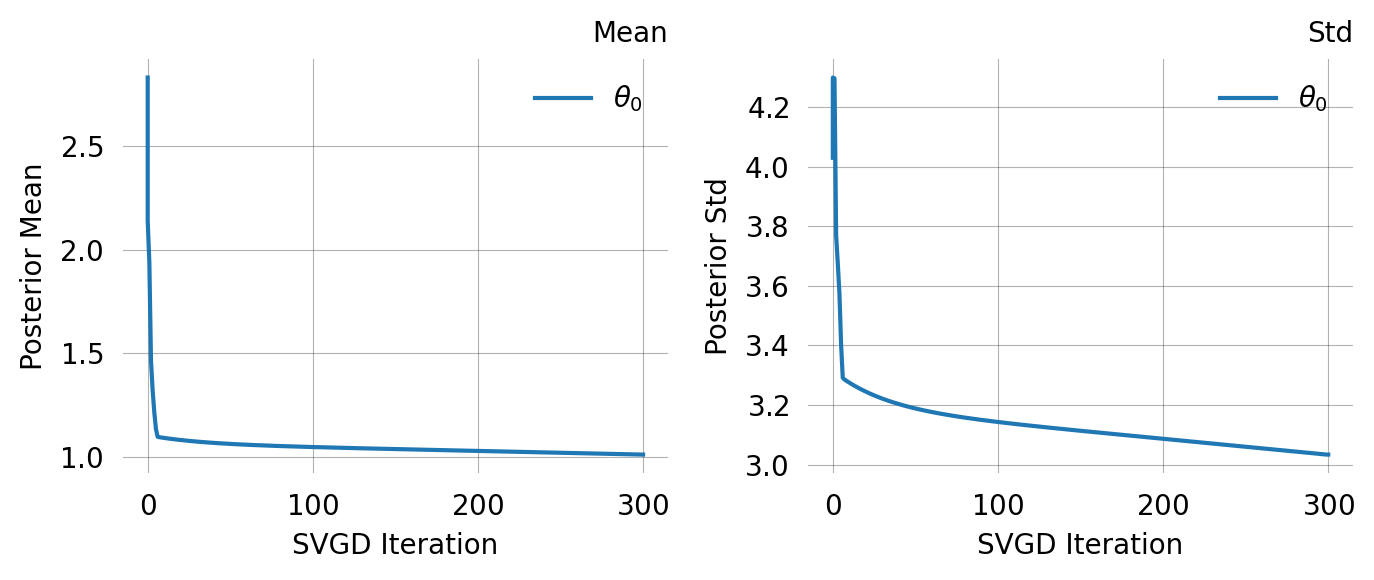

In [59]:
#| label: fig-joint-convergence-hamadryas
#| fig-cap: 'Konvergens af $\hat\theta$ (posterior mean og std) for *P. hamadryas* via joint probability-inferens på $10.000$ subsamplede SNPs.'

sv_jp_bav.plot_convergence()

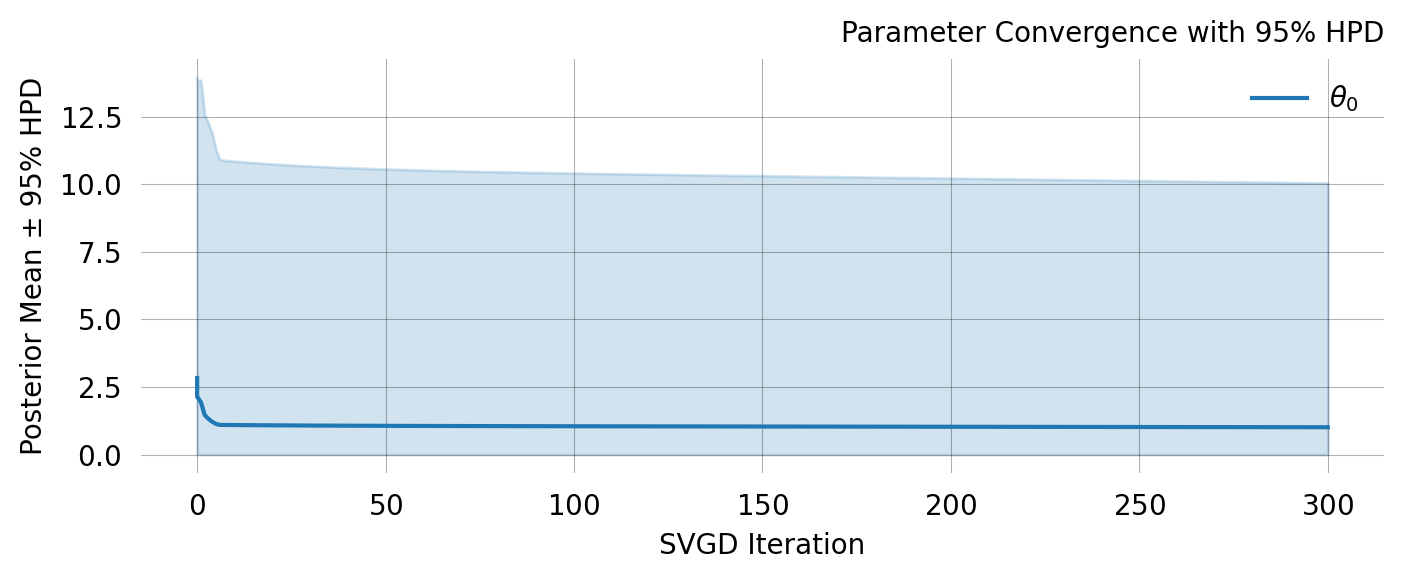

In [60]:
#| label: fig-joint-ci-hamadryas
#| fig-cap: 'Posteriorinterval ($95\%$ HPD) for $\hat\theta$ for *P. hamadryas* via joint probability-inferens, konvergeret over $300$ SVGD-iterationer.'

sv_jp_bav.plot_ci(ci_method='hpd')

In [62]:
# Kovariansmatrix for SFS-grenlængder per population
print('Kovariansmatrix for SFS-grenlængder (n=8) per population')
print('-' * 60)

for name, r in svgd_results.items():
    g_cov = build_coal_graph(8)
    g_cov.update_weights([r['theta']])
    S = g_cov.states()  
    # Reward-vektorer: antal i-ton linjer per tilstand
    rewards = [S[:, i] for i in range(7)]  # 1-ton, 2-ton, 3-ton, 4-ton, 5-ton, 6-ton, 7-ton
    E = [g_cov.expectation(r_i) for r_i in rewards]
    Var = [g_cov.variance(r_i) for r_i in rewards]

    cov_matrix = np.zeros((7, 7))
    for i in range(7):
        for j in range(7):
            if i == j:
                cov_matrix[i, j] = Var[i]
            else:
                var_sum = g_cov.variance(rewards[i] + rewards[j])
                cov_matrix[i, j] = (var_sum - Var[i] - Var[j]) / 2

    labels = ['1-ton', '2-ton', '3-ton', '4-ton', '5-ton', '6-ton', '7-ton']
    df_cov = pd.DataFrame(cov_matrix, index=labels, columns=labels).round(4)
    print(f'\n{name}:')
    print(df_cov)
    print(f'  Cov(1-ton,2-ton)={cov_matrix[0,1]:.4f}  '
          f'(negativt = konkurrerer om grenlængdebudget)')

Kovariansmatrix for SFS-grenlængder (n=8) per population
------------------------------------------------------------

P_cynocephalus:
             1-ton       2-ton       3-ton        4-ton       5-ton  \
1-ton  102649.0080 -11439.2750  -6698.2827   -4516.2664  -3298.3968   
2-ton  -11439.2750  79770.4579  -6698.2827   -4516.2664  -3298.3968   
3-ton   -6698.2827  -6698.2827  66373.8925   -4516.2664  41001.6094   
4-ton   -4516.2664  -4516.2664  -4516.2664  101425.7015 -11468.2719   
5-ton   -3298.3968  -3298.3968  41001.6094  -11468.2719  44553.7290   
6-ton   -2537.2283  42447.8296 -11062.3154   -8804.1822  -7357.9621   
7-ton   44256.5109 -11395.7797  -8525.0871   -6901.2610  -5835.6251   

            6-ton       7-ton  
1-ton  -2537.2283  44256.5109  
2-ton  42447.8296 -11395.7797  
3-ton -11062.3154  -8525.0871  
4-ton  -8804.1822  -6901.2610  
5-ton  -7357.9621  -5835.6251  
6-ton  41864.2670  -5074.4566  
7-ton  -5074.4566  39145.8081  
  Cov(1-ton,2-ton)=-11439.2750  (negativ

In [19]:
df_cov

,1-ton,2-ton,3-ton,4-ton,5-ton,6-ton,7-ton
1-ton,644413.6174,-71813.8904,-42050.7191,-28352.3788,-20706.7935,-15928.3027,277835.1084
2-ton,-71813.8904,500785.8366,-42050.7191,-28352.3788,-20706.7935,266480.5040,-71540.8338
3-ton,-42050.7191,-42050.7191,416684.3984,-28352.3788,257401.3715,-69447.3997,-53519.0970
4-ton,-28352.3788,-28352.3788,-28352.3788,636733.9001,-71995.9282,-55271.2103,-43324.9833
5-ton,-20706.7935,-20706.7935,257401.3715,-71995.9282,279700.9952,-46192.0778,-36635.0962
6-ton,-15928.3027,266480.5040,-69447.3997,-55271.2103,-46192.0778,262816.9944,-31856.6054
7-ton,277835.1084,-71540.8338,-53519.0970,-43324.9833,-36635.0962,-31856.6054,245750.9558


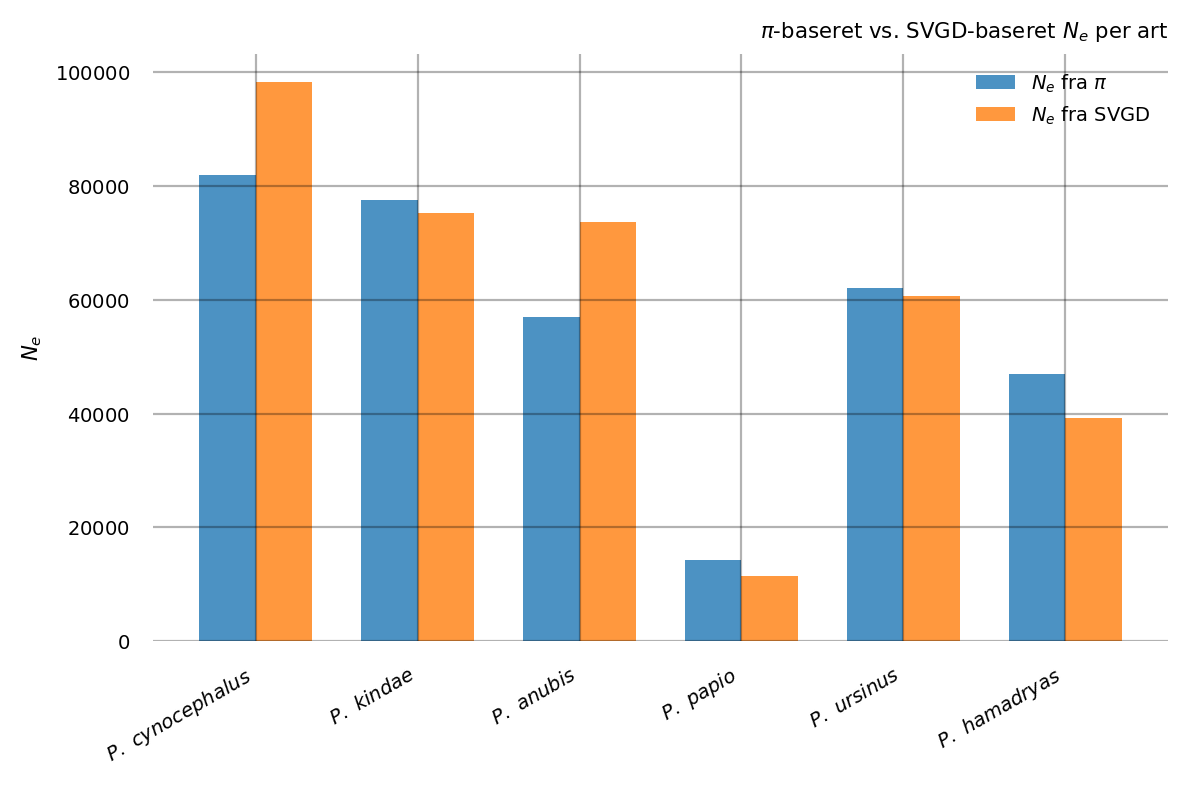

In [ ]:
#| label: fig-ne-svgd
#| fig-cap: 'Sammenligning af $N_e$ estimeret fra SVGD (orange søjler) og fra nukleotiddiversitet $\pi$ (blå søjler) for alle seks *Papio*-populationer. X-aksen viser arterne og y-aksen viser $N_e$.'
#| fig-width: 6
#| fig-height: 3

with sns.plotting_context("paper", font_scale=0.8):
    fig, ax = plt.subplots(figsize=(6, 4))
    short_names = [r'$\it{P.\ cynocephalus}$', r'$\it{P.\ kindae}$', r'$\it{P.\ anubis}$',
                   r'$\it{P.\ papio}$', r'$\it{P.\ ursinus}$', r'$\it{P.\ hamadryas}$']
    names_plt  = list(svgd_results.keys())
    Ne_pi_v    = [N_ref_dict[n] for n in names_plt]
    Ne_svgd_v  = [svgd_results[n]['Ne'] for n in names_plt]
    x = np.arange(len(names_plt)); w = 0.35
    ax.bar(x-w/2, Ne_pi_v,   w, label=r'$N_e$ fra $\pi$', color='C0', alpha=0.8)
    ax.bar(x+w/2, Ne_svgd_v, w, label=r'$N_e$ fra SVGD',  color='C1', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=30, ha='right')
    ax.set_ylabel(r'$N_e$')
    ax.set_title(r'$\pi$-baseret vs. SVGD-baseret $N_e$ per art')
    ax.legend()
    plt.tight_layout(); plt.show()


In [64]:
print('Ratio SVGD/pi per population:')
for n in names_plt:
    ratio = svgd_results[n]['Ne'] / N_ref_dict[n] if N_ref_dict[n] > 0 else np.nan
    print(f'  {n:<22}: SVGD/pi = {ratio:.2f}')

Ratio SVGD/pi per population:
  P_cynocephalus        : SVGD/pi = 1.20
  P_kindae              : SVGD/pi = 0.97
  P_anubis              : SVGD/pi = 1.29
  P_papio               : SVGD/pi = 0.80
  P_ursinus             : SVGD/pi = 0.98
  P_hamadryas           : SVGD/pi = 0.83


## Sensitivitetsanalyse over $\mu$ og $g$

Da $N_e = \hat{\theta}_W / (4\mu)$ og $t = N_e \cdot g$ er alle estimater direkte proportionale med $\mu$ og $g$. Her kvantificeres hvor følsomme konklusionerne er over for disse antagelser.


In [65]:
#| label: tbl-sensitivity
#| tbl-cap: 'Sensitivitetsanalyse for *P. cynocephalus*: $N_e$ og $T_{\\text{coal}}$ under varierende mutationsrate $\\mu \\in [0{,}7; 1{,}1] \\times 10^{-8}$ og generationstid $g \\in [9; 13]$ år. Den estimerede coalescentrate $\\hat{\\theta}$ ændres ikke — kun konverteringen til $N_e$ (individer) og $T_{\\text{coal}}$ (år) afhænger af $\\mu$ og $g$. Generationstiden behandles som en fri parameter da den er usikker for bavianer.'

test_name  = 'P_cynocephalus'
theta_hat  = svgd_results[test_name]['theta']

mu_values = [0.7e-8, 0.9e-8, 1.1e-8]
g_values  = [9, 11, 13]   # G er fri parameter — varieres systematisk

rows_sens = []
for mu_s in mu_values:
    for g_s in g_values:
        Ne_s    = theta_hat / (4 * mu_s)
        T_coal  = Ne_s * g_s  # splitningstid i år = Ne * G
        rows_sens.append({
            f'μ (×10⁻⁸)': round(mu_s/1e-8, 1),
            f'g (år)':     g_s,
            f'Ne':         round(Ne_s),
            f'T_coal (år)': round(T_coal),
        })

df_sens = pd.DataFrame(rows_sens)
df_sens

,μ (×10⁻⁸),g (år),Ne,T_coal (år)
0,0.7,9,126330,1136971
1,0.7,11,126330,1389631
2,0.7,13,126330,1642292
3,0.9,9,98257,884311
4,0.9,11,98257,1080824
5,0.9,13,98257,1277338
6,1.1,9,80392,723527
7,1.1,11,80392,884311
8,1.1,13,80392,1045095


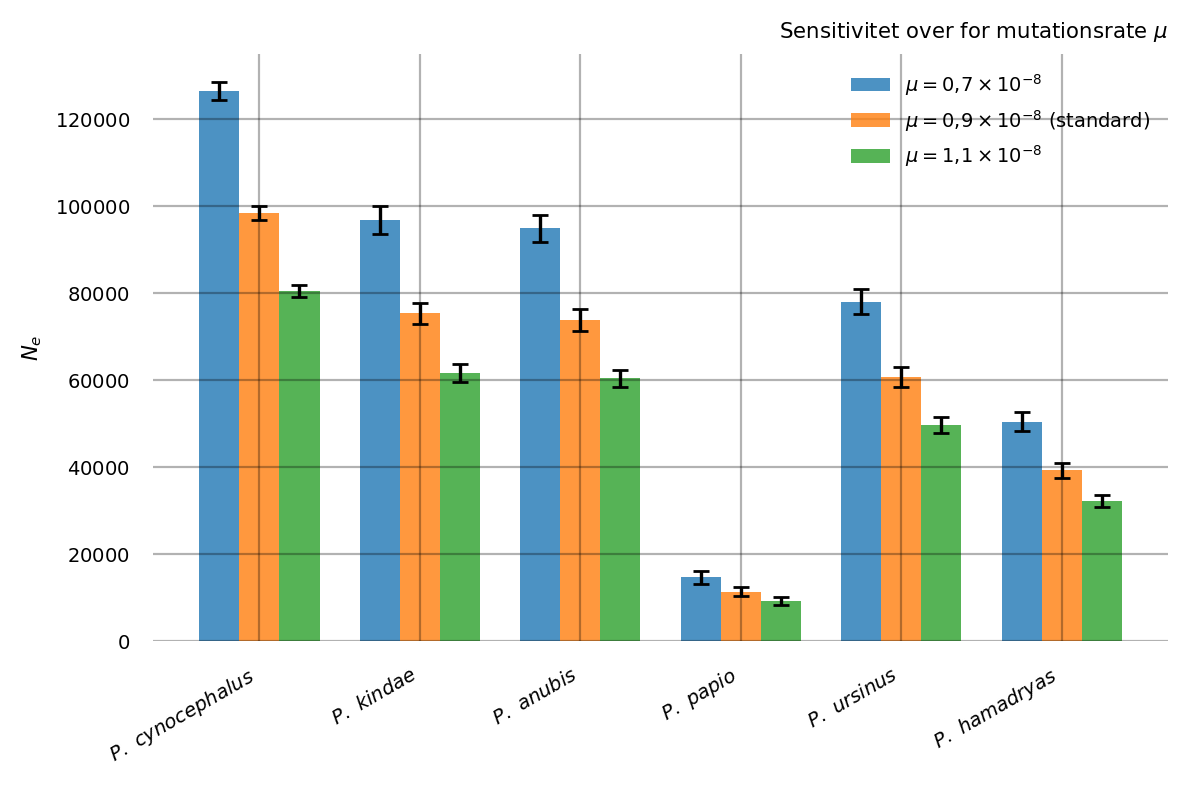

In [66]:
#| label: fig-sensitivity
#| fig-cap: 'Validering af enkeltpopulationsmodellen for *P. cynocephalus* med det estimerede $N_e$. Venstre: histogram af 50.000 msprime-simulerede TMRCA-tider skaleret til coalescentenheder (blå) sammenlignet med phasics analytiske PDF (orange) ved $\theta = 1$ (standard coalescent-enheder). Højre: empirisk CDF fra msprime (blå) sammenlignet med phasics analytiske CDF (orange stiplet). God overensstemmelse bekræfter at skalering og modelimplementering er korrekt.'
#| fig-width: 7
#| fig-height: 4

import matplotlib.pyplot as plt
import numpy as np
with sns.plotting_context("paper", font_scale=0.8):
    pop_names = list(svgd_results.keys())
    short_names = [r'$\it{P.\ cynocephalus}$', r'$\it{P.\ kindae}$', r'$\it{P.\ anubis}$',
                   r'$\it{P.\ papio}$', r'$\it{P.\ ursinus}$', r'$\it{P.\ hamadryas}$']
    x = np.arange(len(pop_names))
    mu_vals_plot = [0.7e-8, 0.9e-8, 1.1e-8]
    mu_labels    = [r'$\mu=0{,}7\times10^{-8}$',
                    r'$\mu=0{,}9\times10^{-8}$ (standard)',
                    r'$\mu=1{,}1\times10^{-8}$']
    colors = ['C0', 'C1', 'C2']
    width  = 0.25

    fig, ax = plt.subplots(figsize=(6, 4))
    for k, (mu, lbl, col) in enumerate(zip(mu_vals_plot, mu_labels, colors)):
        Ne_vals = [svgd_results[n]['theta'] / (4*mu) for n in pop_names]
        Ne_errs = [1.96 * svgd_results[n]['std'] / (4*mu) for n in pop_names]
        ax.bar(x + (k-1)*width, Ne_vals, width,
               yerr=Ne_errs, capsize=3,
               label=lbl, color=col, alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=30, ha='right')
    ax.set_ylabel(r'$N_e$')
    ax.set_title(r'Sensitivitet over for mutationsrate $\mu$')
    ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

## Validering: Kingmans coalescent mod msprime

Som sanity-check validerer jeg enkeltpopulationsmodellen for *P.cynocephalus* ved at simulere data med msprime ved det estimerede $N_e$ og sammenligne TMRCA-fordelingen med phasic-modellens analytiske PDF.

Dette er samme valideringsstrategi som i NB01.

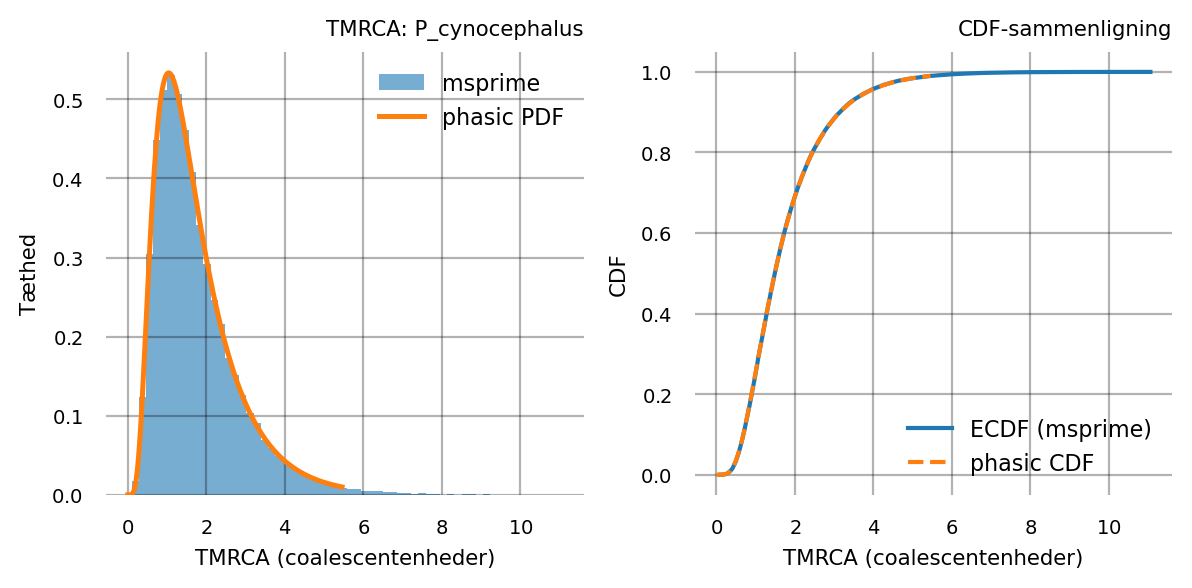

In [68]:
#| label: fig-msprime-val-nb07a
#| fig-cap: 'Validering af enkeltpopulationsmodellen for *P. cynocephalus* med det estimerede $N_e$. Venstre: histogram af $50.000$ msprime-simulerede TMRCA-tider skaleret til coalescentenheder (blå) sammenlignet med phasics analytiske PDF (orange) ved $\theta = 1$ (standard coalescent-enheder). Højre: empirisk CDF fra msprime (blå) sammenlignet med phasics analytiske CDF (orange stiplet).'
#| fig-width: 7
#| fig-height: 3

from scipy.stats import ecdf

val_name  = 'P_cynocephalus'
val_r     = svgd_results[val_name]
theta_hat = val_r['theta']
Ne_hat    = val_r['Ne']

# msprime simulerer i generationer — skaler til coalescent-enheder ved /( 2*Ne)
N_VAL_BV = 50000
rng_bv = np.random.default_rng(42)
tmrca_bv = []

for _ in range(N_VAL_BV):
    ts = msprime.sim_ancestry(
        samples=N_SUB,
        ploidy=1,
        population_size=Ne_hat,
        sequence_length=1,
        recombination_rate=0,
        random_seed=int(rng_bv.integers(1, 2**31)),
    )
    tmrca_bv.append(ts.first().time(ts.first().root))

tmrca_bv = np.array(tmrca_bv)
tmrca_scaled_bv = tmrca_bv / Ne_hat   # ploidy=1: divider kun med Ne, ikke 2*Ne
# Byg graf med theta=1 (standard coalescent-enheder)
g_val = build_coal_graph(N_SUB)
g_val.update_weights([1.0])   # theta=1 svarer til standard coalescent-enheder

x_val = np.linspace(0, np.percentile(tmrca_scaled_bv, 99), 200)

with sns.plotting_context("paper", font_scale=0.8):
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    axes[0].hist(tmrca_scaled_bv, bins=60, density=True, alpha=0.6, label='msprime')
    axes[0].plot(x_val, g_val.pdf(x_val), 'C1', lw=1.8, label='phasic PDF')
    axes[0].set_xlabel('TMRCA (coalescentenheder)')
    axes[0].set_ylabel('Tæthed')
    axes[0].set_title(f'TMRCA: {val_name}')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    res_ecdf = ecdf(tmrca_scaled_bv)
    x_ecdf = np.sort(tmrca_scaled_bv)
    axes[1].plot(x_ecdf, res_ecdf.cdf.evaluate(x_ecdf), label='ECDF (msprime)', lw=1.5)
    axes[1].plot(x_val, g_val.cdf(x_val), 'C1--', lw=1.5, label='phasic CDF')
    axes[1].set_xlabel('TMRCA (coalescentenheder)')
    axes[1].set_ylabel('CDF')
    axes[1].set_title('CDF-sammenligning')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [69]:
rel_diff = abs(tmrca_scaled_bv.mean() - g_val.expectation()) / g_val.expectation() * 100

print(f"msprime mean (skaleret): {tmrca_scaled_bv.mean():.4f}")
print(f"phasic E[H]:             {g_val.expectation():.4f}")
print(f"Relativ afvigelse:       {rel_diff:.2f}%  (bør være < 5%)")

msprime mean (skaleret): 1.7511
phasic E[H]:             1.7500
Relativ afvigelse:       0.07%  (bør være < 5%)


## Gem resultater til NB07B

In [70]:
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# Population summary
rows = []
for name, df in populations.items():
    r = svgd_results[name]
    rows.append({
        'population':  name,
        'n_haplotypes': r['n_hap'],
        'pi':           nucleotide_diversity(df),
        'theta_W':      watterson_theta(df),
        'N_ref':        N_ref_dict[name],
        'tajimas_d':    tajimas_d(df),
        'theta_mean':   r['theta'],
        'theta_std':    r['std'],
        'Ne_svgd':      r['Ne'],
    })
pd.DataFrame(rows).to_csv(
    RESULTS_DIR / "population_summary.csv", index=False)

# SFS
pd.DataFrame([
    {'population': n,
     **{f'b{i+1}': v for i, v in enumerate(sfs_unfolded_min[n])}}
    for n in populations
]).to_csv(RESULTS_DIR / "sfs_unfolded.csv", index=False)

pd.DataFrame([
    {'population': n,
     **{f'b{i+1}': v for i, v in enumerate(sfs_folded_full[n])}}
    for n in populations
]).to_csv(RESULTS_DIR / "sfs_folded.csv", index=False)

# Ne reference
pd.DataFrame([
    {'population': n, 'N_ref': v}
    for n, v in N_ref_dict.items()
]).to_csv(RESULTS_DIR / "N_ref.csv", index=False)

# SVGD-resultater — inkl. Ne_low og Ne_hi til NB07B
pd.DataFrame([
    {
        'population':   n,
        'theta_mean':   r['theta'],
        'theta_std':    r['std'],
        'Ne':           r['Ne'],
        'Ne_low':       r.get('Ne_low', np.nan),
        'Ne_hi':        r.get('Ne_hi',  np.nan),
        'E_H_yr':       r.get('E_H_yr', np.nan),
        'n_haplotypes': r['n_hap'],
    }
    for n, r in svgd_results.items()
]).to_csv(RESULTS_DIR / "svgd_results.csv", index=False)

# SNP-filer per population
for name, df in populations.items():
    safe     = name.replace('. ', '_').replace('.', '').replace(' ', '_')
    filepath = RESULTS_DIR / f"snp_{safe}.csv"
    df.to_csv(filepath, index=False)

# Verifikation
print("Gemte filer:")
expected = [
    "population_summary.csv",
    "sfs_unfolded.csv",
    "sfs_folded.csv",
    "N_ref.csv",
    "svgd_results.csv",
] + [
    f"snp_{n.replace('. ', '_').replace('.', '').replace(' ', '_')}.csv"
    for n in populations
]

all_ok = True
for fname in expected:
    p = RESULTS_DIR / fname
    if p.exists():
        print(f" {p.name:<45} {p.stat().st_size/1024:.1f} KB")
    else:
        print(f" MANGLER: {fname}")
        all_ok = False

print()
if all_ok:
    print(f"Alle {len(expected)} filer gemt korrekt")
else:
    print("ADVARSEL: Nogle filer mangler — tjek ovenstående")

# Verificer at NB07B kan indlæse svgd_results korrekt
df_check = pd.read_csv(RESULTS_DIR / "svgd_results.csv")
print(f"\nsvgd_results.csv kolonner: {list(df_check.columns)}")
print(df_check[['population', 'Ne', 'Ne_low', 'Ne_hi']].to_string(index=False))

Gemte filer:
 population_summary.csv                        1.0 KB
 sfs_unfolded.csv                              0.4 KB
 sfs_folded.csv                                2.2 KB
 N_ref.csv                                     0.2 KB
 svgd_results.csv                              0.7 KB
 snp_P_cynocephalus.csv                        20590.0 KB
 snp_P_kindae.csv                              11585.8 KB
 snp_P_anubis.csv                              15826.1 KB
 snp_P_papio.csv                               1539.7 KB
 snp_P_ursinus.csv                             5049.2 KB
 snp_P_hamadryas.csv                           6451.3 KB

Alle 11 filer gemt korrekt

svgd_results.csv kolonner: ['population', 'theta_mean', 'theta_std', 'Ne', 'Ne_low', 'Ne_hi', 'E_H_yr', 'n_haplotypes']
    population           Ne       Ne_low        Ne_hi
P_cynocephalus 98256.762078 96655.848889 99857.675266
      P_kindae 75234.614054 72803.711199 77665.516910
      P_anubis 73743.615851 71310.293431 76176.938270
       